In [1]:
import os
import pandas as pd

os.getcwd()


import peakweather

print("PeakWeather version ",peakweather.__version__)

from peakweather import PeakWeatherDataset

#Load Local Dataset
# Exclude: rain gauge stations (142) & sunshine variable
ds = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        extended_topo_vars="DEM",
                        station_type="meteo_station")

PeakWeather version  0.2.1


In [10]:
import sys
import os
sys.path.insert(0, os.getcwd())

In [13]:
from data.visualize import *


ModuleNotFoundError: No module named 'data'

### Spatial Embedding

In [9]:
print("Check number of stations:", len(ds.stations_table))

Check number of stations: 156


In [10]:
ds.stations_table.columns

Index(['station_name', 'latitude', 'longitude', 'station_height',
       'swiss_easting', 'swiss_northing', 'ASPECT_2000M_SIGRATIO1',
       'WE_DERIVATIVE_2000M_SIGRATIO1', 'TPI_2000M',
       'SN_DERIVATIVE_10000M_SIGRATIO1', 'dem',
       'SN_DERIVATIVE_2000M_SIGRATIO1', 'SLOPE_10000M_SIGRATIO1',
       'ASPECT_10000M_SIGRATIO1', 'SLOPE_2000M_SIGRATIO1', 'STD_2000M',
       'STD_10000M', 'TPI_10000M', 'WE_DERIVATIVE_10000M_SIGRATIO1',
       'station_type'],
      dtype='str')

In [11]:
station = 'ABO'

In [16]:
coordinates = ds.stations_table[['swiss_easting', 'swiss_northing']] # spatial embedding (lat, lon) → [sin(Bx), cos(Bx)]

#Call one station⁄
ds.stations_table.drop(columns=["latitude", "longitude", "station_name", "station_type"]).loc[station]

station_name                           Adelboden
station_height                           1321.38
swiss_easting                     2609371.616986
swiss_northing                    1148939.073438
ASPECT_2000M_SIGRATIO1                124.863129
WE_DERIVATIVE_2000M_SIGRATIO1          -0.167379
TPI_2000M                             -53.303345
SN_DERIVATIVE_10000M_SIGRATIO1         -0.026807
dem                                  1317.771851
SN_DERIVATIVE_2000M_SIGRATIO1           0.116605
SLOPE_10000M_SIGRATIO1                  1.702339
ASPECT_10000M_SIGRATIO1                25.582031
SLOPE_2000M_SIGRATIO1                  11.529667
STD_2000M                             120.940262
STD_10000M                            374.830623
TPI_10000M                           -443.723877
WE_DERIVATIVE_10000M_SIGRATIO1         -0.012833
station_type                       meteo_station
Name: ABO, dtype: object

### Temporal Embedding

In [17]:
ds.get_observations(station).head()

nat_abbr                         ABO                                        \
name                        humidity precipitation    pressure temperature   
datetime                                                                     
2017-01-01 00:00:00+00:00  30.500000           0.0  874.900024         1.1   
2017-01-01 00:10:00+00:00  30.700001           0.0  874.900024         1.2   
2017-01-01 00:20:00+00:00  34.599998           0.0  874.799988         1.2   
2017-01-01 00:30:00+00:00  27.900000           0.0  874.700012         2.0   
2017-01-01 00:40:00+00:00  32.000000           0.0  874.599976         0.5   

nat_abbr                                                       
name                      wind_direction wind_gust wind_speed  
datetime                                                       
2017-01-01 00:00:00+00:00          356.0       1.3        0.8  
2017-01-01 00:10:00+00:00          277.0       1.8        1.0  
2017-01-01 00:20:00+00:00          258.0       1.1        0.6  
2017-01-01 00:30:00+00:00          306.0       1.5        0.9  
2017-01-01 00:40:00+00:00          304.0       1.4        0.7

In [18]:
print("Start recording", ds.get_observations(station).index[0].date())
print("End recording", ds.get_observations(station).index[-1].date())

Start recording 2017-01-01
End recording 2025-10-13


In [19]:
ds.get_observations(station).index[-1] - ds.get_observations(station).index[0]

Timedelta('3207 days 23:50:00')

In [20]:
3207/365

8.786301369863013

In [21]:
ds.get_observations(station).index

DatetimeIndex(['2017-01-01 00:00:00+00:00', '2017-01-01 00:10:00+00:00',
               '2017-01-01 00:20:00+00:00', '2017-01-01 00:30:00+00:00',
               '2017-01-01 00:40:00+00:00', '2017-01-01 00:50:00+00:00',
               '2017-01-01 01:00:00+00:00', '2017-01-01 01:10:00+00:00',
               '2017-01-01 01:20:00+00:00', '2017-01-01 01:30:00+00:00',
               ...
               '2025-10-13 22:20:00+00:00', '2025-10-13 22:30:00+00:00',
               '2025-10-13 22:40:00+00:00', '2025-10-13 22:50:00+00:00',
               '2025-10-13 23:00:00+00:00', '2025-10-13 23:10:00+00:00',
               '2025-10-13 23:20:00+00:00', '2025-10-13 23:30:00+00:00',
               '2025-10-13 23:40:00+00:00', '2025-10-13 23:50:00+00:00'],
              dtype='datetime64[ns, UTC]', name='datetime', length=461952, freq='10min')

### Variables

In [22]:
ds.get_observations(station).iloc[0]

nat_abbr  name          
ABO       humidity           30.500000
          precipitation       0.000000
          pressure          874.900024
          temperature         1.100000
          wind_direction    356.000000
          wind_gust           1.300000
          wind_speed          0.800000
Name: 2017-01-01 00:00:00+00:00, dtype: float32

In [ ]:
ds.available_parameters

#### Explore Variables Data

In [100]:
ds_day = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        freq = "d",
                        station_type="meteo_station")

In [101]:
df, mask = ds_day.get_observations(
    #first_date="2024-08-02 16:32",
    #last_date="2024-08-06 23:26",
    return_mask=True,
)

long_df = mask.stack(0).rename_axis(["datetime","nat_abbr"]).reset_index()
df_time = long_df.groupby(["datetime"]).sum().drop(columns=["nat_abbr"]).reset_index()
df_station = long_df.drop(columns=["datetime"]).groupby(["nat_abbr"]).sum().reset_index()

variables = df_station.columns[df_station.columns != 'nat_abbr']

In [102]:
df_station.head()

name,nat_abbr,humidity,precipitation,pressure,temperature,wind_direction,wind_gust,wind_speed
0,ABO,3209,3205,3209,3209,3209,3209,3209
1,AEG,0,0,0,0,3205,3205,3205
2,AIG,3209,3209,3209,3209,3209,3209,3209
3,ALT,3209,3206,3209,3209,3209,3209,3209
4,AND,3209,3193,3209,3208,3209,3209,3209


In [103]:
# Count how many variables are <1600 for each station
df_station["count_true"] = (df_station[variables] < 1600).sum(axis=1)

# Keep station name and the count
result = df_station[["nat_abbr", "count_true"]]

print("Number of Stations with less than 50% data recorded ", len(df_station["count_true"] != 0))

df_station[df_station["count_true"] != 0].sort_values("count_true", ascending=False)

Number of Stations with less than 50% data recorded  156


name,nat_abbr,humidity,precipitation,pressure,temperature,wind_direction,wind_gust,wind_speed,count_true
110,PFA,1041,1041,1041,1041,1041,1041,1041,7
1,AEG,0,0,0,0,3205,3205,3205,4
115,PRE,0,0,0,0,3205,3205,3205,4
82,LAC,3207,3208,0,3207,0,0,0,4
116,PSI,3209,3209,3209,3209,0,0,0,3
66,GRC,3208,3207,3209,3208,0,0,0,3
140,STK,0,0,3209,0,3208,3208,3208,3
129,SCM,0,0,3209,0,3204,3204,3204,3
118,QUI,0,0,3209,0,3209,3209,3209,3
77,ILZ,3165,3201,3202,3202,0,0,0,3


In [104]:
df_PFA, mask_PFA = ds.get_observations("PFA", return_mask= True)

In [105]:
df_PFA[mask_PFA].dropna()

nat_abbr                         PFA                                        \
name                        humidity precipitation    pressure temperature   
datetime                                                                     
2022-12-08 09:00:00+00:00  93.000000           0.0  947.500000         0.9   
2022-12-08 09:10:00+00:00  92.300003           0.0  947.299988         0.9   
2022-12-08 09:20:00+00:00  91.599998           0.0  947.299988         1.2   
2022-12-08 09:30:00+00:00  89.699997           0.0  947.299988         1.3   
2022-12-08 09:40:00+00:00  89.599998           0.0  947.299988         1.4   
...                              ...           ...         ...         ...   
2025-10-13 23:10:00+00:00  85.800003           0.0  960.799988        10.3   
2025-10-13 23:20:00+00:00  86.000000           0.0  960.799988        10.2   
2025-10-13 23:30:00+00:00  87.099998           0.0  960.799988        10.1   
2025-10-13 23:40:00+00:00  88.199997           0.0  960.799988        10.1   
2025-10-13 23:50:00+00:00  88.599998           0.0  960.799988        10.0   

nat_abbr                                                       
name                      wind_direction wind_gust wind_speed  
datetime                                                       
2022-12-08 09:00:00+00:00          279.0       1.0        0.4  
2022-12-08 09:10:00+00:00          209.0       1.0        0.5  
2022-12-08 09:20:00+00:00          139.0       1.1        0.5  
2022-12-08 09:30:00+00:00           75.0       1.1        0.5  
2022-12-08 09:40:00+00:00           99.0       1.1        0.4  
...                                  ...       ...        ...  
2025-10-13 23:10:00+00:00           58.0       2.1        1.4  
2025-10-13 23:20:00+00:00           32.0       2.1        1.5  
2025-10-13 23:30:00+00:00           28.0       2.0        1.5  
2025-10-13 23:40:00+00:00           21.0       2.5        1.5  
2025-10-13 23:50:00+00:00           38.0       2.2        1.6  

[149672 rows x 7 columns]

In [106]:
PFA_station = ds.stations_table.loc["PFA"]
easting = PFA_station["swiss_easting"]
northing = PFA_station["swiss_northing"]

In [126]:
from data.visualize import plot_stations_on_dem, StationMarker

ImportError: attempted relative import with no known parent package

In [82]:
path_swissshape = "/Users/aureliedejong/Documents/ETH/_DAS Project/swissboundaries3d_2026-01_2056_5728.shp.zip"
# specify layer explicitly
switzerland = gpd.read_file(
    path_swissshape,
    layer="swissBOUNDARIES3D_1_5_TLM_LANDESGEBIET"
)
switzerland = switzerland.to_crs("EPSG:2056")

In [87]:

topo = ds.load_topography()
dem = topo["topo_DEM"].dem

# coarsen grid for visualization
#dem_small = dem.coarsen(x=10, y=10, boundary="trim").mean()

# Clip DEM to Switzerland
dem_ch = dem.rio.clip(switzerland.geometry, switzerland.crs, drop=False)

# Downsample for faster plotting
dem_small = dem.coarsen(x=10, y=10, boundary="trim").mean()
dem_ch_small = dem_ch.coarsen(x=10, y=10, boundary="trim").mean()

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


In [98]:
minx, miny, maxx, maxy = switzerland.total_bounds
# cropped DEM
dem_cropped = dem_ch_small.sel(
    x=slice(minx, maxx),
    y=slice(miny, maxy)
)
dem_small_cropped = dem_small.sel(x=slice(minx, maxx), y=slice(miny, maxy))

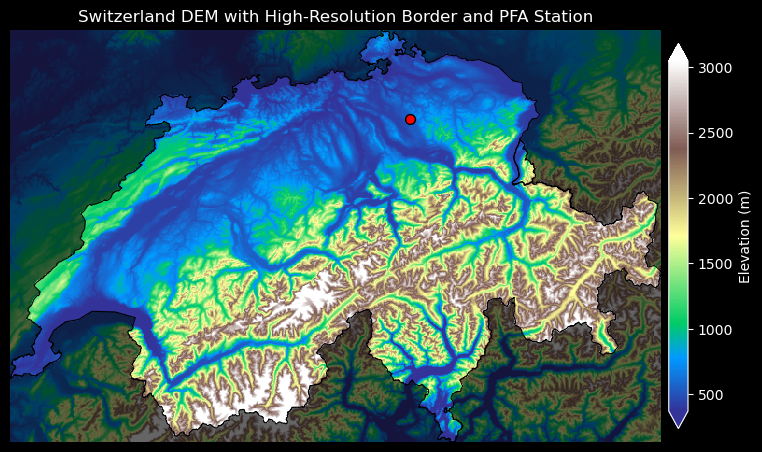

In [113]:
fig, ax = plt.subplots(figsize=(10,10))

# Full DEM in background, low opacity
dem_small_cropped.plot(ax=ax, cmap="terrain", alpha =0.4, robust=True, add_labels=False, add_colorbar=False)

# Switzerland DEM on top, higher opacity
dem_cropped.plot(ax=ax,
                 cmap="terrain",
                 robust=True,
                 add_labels=False,
                 cbar_kwargs={
                    "label": "Elevation (m)",
                    "shrink": 0.5,        # make colorbar smaller
                    "pad": 0.01           # reduce space between plot and colorbar
                })

# Border
switzerland.boundary.plot(ax=ax, color="black", linewidth=0.8)

# Add station point
ax.scatter(
    easting, northing,
    color="red",
    edgecolor="black",
    s=50,  # marker size
    marker="o",
    zorder=10,
    label="PFA Station"
)

plt.title("Switzerland DEM with High-Resolution Border and PFA Station")
ax.axis("off")
plt.show()

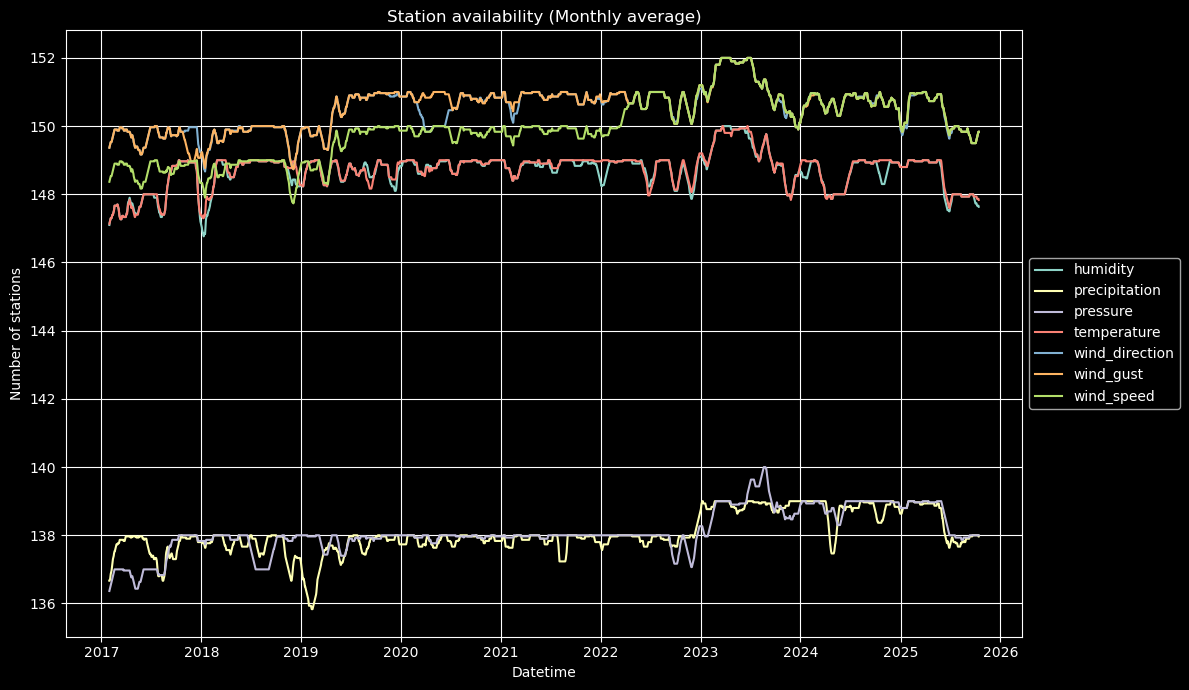

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

for v in variables:
    ax.plot(
        df_time["datetime"],
        df_time[v].rolling(30).mean(),
        label=v
    )

ax.set_title("Station availability (Monthly average)")
ax.set_ylabel("Number of stations")
ax.set_xlabel("Datetime")

# legend on the right side
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

ax.grid(True)

plt.tight_layout()
plt.show()